# StochasticEoS
FC-Tanh network (2 × 200 hidden units, tanh) trained with MSE loss on CIFAR-10.

In [1]:
import os
from google.colab import drive

drive.mount('/content/drive')
os.chdir('/content/drive/My Drive/Research/StochasticEoS')

Mounted at /content/drive


In [2]:
import torch
import torch.optim as optim
from model import FCTanh
from data import get_cifar10_loaders
from train import train_epoch, evaluate
from utils import get_device

## Hyperparameters

In [3]:
LR         = 0.1
BATCH_SIZE = 128
EPOCHS     = 100
VERBOSE    = 5       # print progress every this many epochs
DATA_DIR   = '/content/drive/My Drive/Research/data/'

## Setup

In [4]:
device = get_device()
print(f'Using device: {device}')

train_loader, test_loader = get_cifar10_loaders(DATA_DIR, batch_size=BATCH_SIZE)

model = FCTanh().to(device)
optimizer = optim.SGD(model.parameters(), lr=LR)

Using device: cuda


## Training

In [ ]:
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, device)
    te_loss, te_acc = evaluate(model, test_loader, device)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['test_loss'].append(te_loss)
    history['test_acc'].append(te_acc)

    if VERBOSE > 0 and epoch % VERBOSE == 0:
        print(f'Epoch {epoch:>{len(str(EPOCHS))}d}/{EPOCHS} | '
              f'Train loss {tr_loss:.4f}, acc {tr_acc:.3f} | '
              f'Test  loss {te_loss:.4f}, acc {te_acc:.3f}')

KeyboardInterrupt: 

## Results

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='train')
ax1.plot(history['test_loss'],  label='test')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE Loss')
ax1.set_title('Loss'); ax1.legend()

ax2.plot(history['train_acc'], label='train')
ax2.plot(history['test_acc'],  label='test')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy'); ax2.legend()

plt.tight_layout()
plt.show()

## Full-Batch Gradient Descent

In [ ]:
from data import get_cifar10_subset
from train import fullbatch_gd

FB_LR    = 0.1
FB_STEPS = 5000

fb_dataset = get_cifar10_subset(DATA_DIR, samples_per_class=500)
fb_model   = FCTanh().to(device)

fb_model, fb_loss, fb_acc, fb_sharpness, fb_checkpoints = fullbatch_gd(
    fb_model, criterion=torch.nn.MSELoss(),
    dataset=fb_dataset, eta=FB_LR, num_steps=FB_STEPS, eval_freq=50
)

Step   50/5000 | Loss 0.0817 | Acc 0.360 | Sharpness 15.6579
Step  100/5000 | Loss 0.0784 | Acc 0.412 | Sharpness 15.2845
Step  150/5000 | Loss 0.0766 | Acc 0.441 | Sharpness 15.1738
Step  200/5000 | Loss 0.0752 | Acc 0.470 | Sharpness 15.1866
Step  250/5000 | Loss 0.0740 | Acc 0.491 | Sharpness 15.2704
Step  300/5000 | Loss 0.0730 | Acc 0.505 | Sharpness 15.4038
Step  350/5000 | Loss 0.0720 | Acc 0.518 | Sharpness 15.5771
Step  400/5000 | Loss 0.0711 | Acc 0.533 | Sharpness 15.7851
Step  450/5000 | Loss 0.0702 | Acc 0.549 | Sharpness 16.0250
Step  500/5000 | Loss 0.0694 | Acc 0.563 | Sharpness 16.2957
Step  550/5000 | Loss 0.0686 | Acc 0.576 | Sharpness 16.5970
Step  600/5000 | Loss 0.0678 | Acc 0.588 | Sharpness 16.9283
Step  650/5000 | Loss 0.0670 | Acc 0.600 | Sharpness 17.2894
Step  700/5000 | Loss 0.0661 | Acc 0.609 | Sharpness 17.6797
Step  750/5000 | Loss 0.0653 | Acc 0.620 | Sharpness 18.0984
Step  800/5000 | Loss 0.0645 | Acc 0.634 | Sharpness 18.5452
Step  850/5000 | Loss 0.

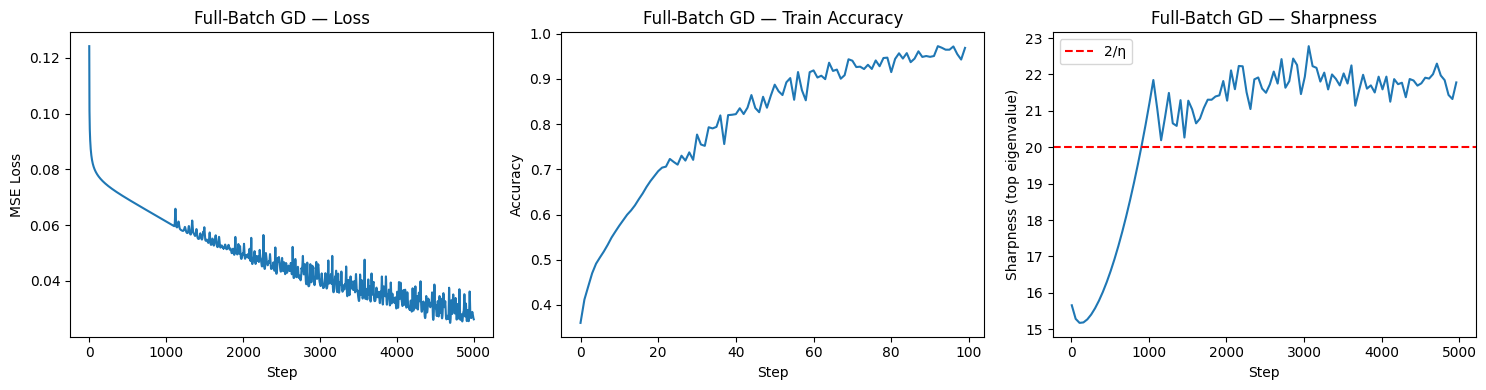

In [ ]:
from matplotlib import pyplot as plt

steps = list(range(10, FB_STEPS + 1, 50))
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

ax1.plot(fb_loss)
ax1.set_xlabel('Step'); ax1.set_ylabel('MSE Loss')
ax1.set_title('Full-Batch GD — Loss')

ax2.plot(fb_acc)
ax2.set_xlabel('Step'); ax2.set_ylabel('Accuracy')
ax2.set_title('Full-Batch GD — Train Accuracy')

ax3.plot(steps, fb_sharpness)
ax3.axhline(2 / FB_LR, color='r', linestyle='--', label='2/η')
ax3.set_xlabel('Step'); ax3.set_ylabel('Sharpness (top eigenvalue)')
ax3.set_title('Full-Batch GD — Sharpness')
ax3.legend()

plt.tight_layout()
plt.show()

In [ ]:
torch.save(fb_checkpoints[18], './checkpoint_step.pt')

## Constrained Training

In [6]:
from train import constraint_training

CONSTRAINED_STEPS = 100
CONSTRAINED_BATCH  = 50000
LR = 0.1

init_params = torch.load('checkpoint_step.pt')
dataset = train_loader.dataset

c_model, c_stats, c_loss_history = constraint_training(
    model, criterion=torch.nn.MSELoss(), dataset=dataset,
    eta=LR, num_steps=CONSTRAINED_STEPS, batch_size=CONSTRAINED_BATCH,
    init_params=init_params, destination_folder='/content/drive/My Drive/Research/StochasticEoS/constraint_ckpt',
)

Step 1/100 | Loss 0.0791 | Sharp Grad Norm^2 0.0000
Step 2/100 | Loss 0.0790 | Sharp Grad Norm^2 0.0000
Step 3/100 | Loss 0.0789 | Sharp Grad Norm^2 0.0000
Step 4/100 | Loss 0.0788 | Sharp Grad Norm^2 0.0000
Step 5/100 | Loss 0.0788 | Sharp Grad Norm^2 0.0000
Step 6/100 | Loss 0.0787 | Sharp Grad Norm^2 0.0000
Step 7/100 | Loss 0.0786 | Sharp Grad Norm^2 0.0000
Step 8/100 | Loss 0.0786 | Sharp Grad Norm^2 0.0000
Step 9/100 | Loss 0.0785 | Sharp Grad Norm^2 0.0000
Step 10/100 | Loss 0.0785 | Sharp Grad Norm^2 0.0000
Step 11/100 | Loss 0.0784 | Sharp Grad Norm^2 0.0000
Step 12/100 | Loss 0.0784 | Sharp Grad Norm^2 0.0000
Step 13/100 | Loss 0.0783 | Sharp Grad Norm^2 0.0000
Step 14/100 | Loss 0.0783 | Sharp Grad Norm^2 0.0000
Step 15/100 | Loss 0.0783 | Sharp Grad Norm^2 0.0000
Step 16/100 | Loss 0.0782 | Sharp Grad Norm^2 0.0000
Step 17/100 | Loss 0.0782 | Sharp Grad Norm^2 0.0000
Step 18/100 | Loss 0.0781 | Sharp Grad Norm^2 0.0000
Step 19/100 | Loss 0.0781 | Sharp Grad Norm^2 0.0000
St

In [ ]:
NUM_RUNS = 10

all_stats = []
all_loss_histories = []

for run in range(NUM_RUNS):
    _, run_stats, run_loss_history = constraint_training(
        model, criterion=torch.nn.MSELoss(), dataset=dataset,
        eta=LR, num_steps=CONSTRAINED_STEPS, batch_size=CONSTRAINED_BATCH,
        init_params=init_params,
    )
    all_stats.append(run_stats)
    all_loss_histories.append(run_loss_history)
    print(f'Run {run + 1}/{NUM_RUNS} done')

## Predicted Dynamics

In [ ]:
from train import generate_predicted_dynamic


def run_predicted_dynamics(model, criterion, dataset, eta, num_steps, batch_size,
                           ckpt_dir, init_state_dict, num_runs, save_path):
    """
    Run generate_predicted_dynamic num_runs times and save all results.

    Each run draws a fresh independent mini-batch trajectory (gradient noise),
    producing one tuple of length-num_steps lists per run.

    Args:
        model:            PyTorch model (parameters overwritten internally).
        criterion:        Loss function.
        dataset:          Full dataset.
        eta:              Learning rate.
        num_steps:        Number of steps T per run.
        batch_size:       Mini-batch size for gradient-noise collection.
        ckpt_dir:         Directory with 'ckpt_{t}.pt' for t = 0, ..., T.
        init_state_dict:  Initial model state dict (theta_0).
        num_runs:         Number of independent repetitions.
        save_path:        File path (.pt) to save results with torch.save.

    Returns:
        results: dict with keys
            'x_hat':        list of num_runs lists of x_hat_t
            'y_hat':        list of num_runs lists of y_hat_t
            'alpha':        list of num_runs lists of alpha_t
            'beta':         list of num_runs lists of beta_t
            'noise_u':      list of num_runs lists of <xi_t, u_t>
            'noise_sharp':  list of num_runs lists of <xi_t, nabla_S_t>
        (also saved to save_path)
    """
    all_x_hat, all_y_hat = [], []
    all_alpha, all_beta = [], []
    all_noise_u, all_noise_sharp = [], []

    for run in range(num_runs):
        x_hat, y_hat, alpha, beta, noise_u, noise_sharp = generate_predicted_dynamic(
            model, criterion, dataset, eta, num_steps, batch_size,
            ckpt_dir, init_state_dict,
        )
        all_x_hat.append(x_hat)
        all_y_hat.append(y_hat)
        all_alpha.append(alpha)
        all_beta.append(beta)
        all_noise_u.append(noise_u)
        all_noise_sharp.append(noise_sharp)
        print(f'Run {run + 1}/{num_runs} done')

    results = {
        'x_hat': all_x_hat,
        'y_hat': all_y_hat,
        'alpha': all_alpha,
        'beta':  all_beta,
        'noise_u':     all_noise_u,
        'noise_sharp': all_noise_sharp,
    }
    torch.save(results, save_path)
    print(f'Saved predicted dynamics to {save_path}')
    return results

In [ ]:
PRED_RUNS       = 10
PRED_STEPS      = CONSTRAINED_STEPS
PRED_BATCH_SIZE = 128
CKPT_DIR        = '/content/drive/My Drive/Research/StochasticEoS/constraint_ckpt'
PRED_SAVE_PATH  = '/content/drive/My Drive/Research/StochasticEoS/predicted_dynamics.pt'

pred_results = run_predicted_dynamics(
    model=model,
    criterion=torch.nn.MSELoss(),
    dataset=dataset,
    eta=LR,
    num_steps=PRED_STEPS,
    batch_size=PRED_BATCH_SIZE,
    ckpt_dir=CKPT_DIR,
    init_state_dict=init_params,
    num_runs=PRED_RUNS,
    save_path=PRED_SAVE_PATH,
)